# Gaussian Blur, Medical Images

### Import resources and display image

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [2]:
IMG = '../../../img'

In [11]:
!ls $IMG/*brain*

../../../img/brain_MR.jpg       ../../../img/noisy_brain_MR.jpg


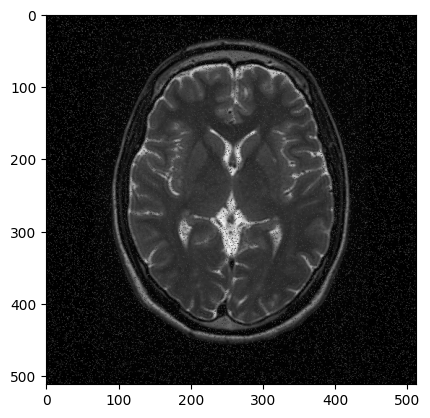

In [12]:
#image = cv2.imread(f'{IMG}/brain_MR.jpg')
image = cv2.imread(f'{IMG}/noisy_brain_MR.jpg')
image_copy = np.copy(image)
image_copy = cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB)
plt.imshow(image_copy);

### Gaussian blur the image

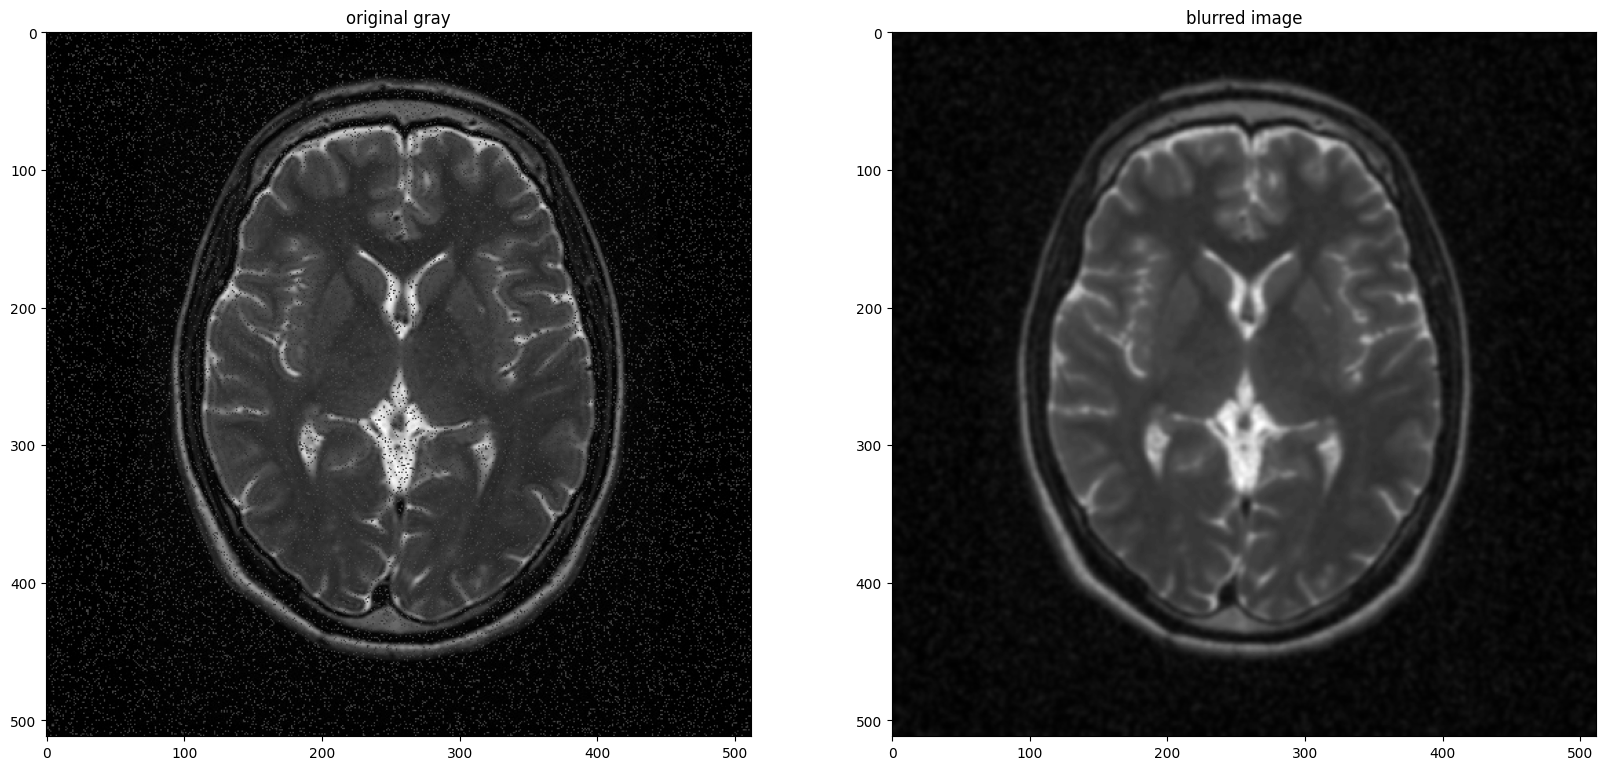

In [14]:
gray = cv2.cvtColor(image_copy, cv2.COLOR_RGB2GRAY)
kernel = (9, 9)
gray_blur = cv2.GaussianBlur(gray, kernel, 0)

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,10))
ax1.set_title('original gray')
ax1.imshow(gray, cmap='gray')
ax2.set_title('blurred image')
ax2.imshow(gray_blur, cmap='gray');

### Test performance with a high-pass filter

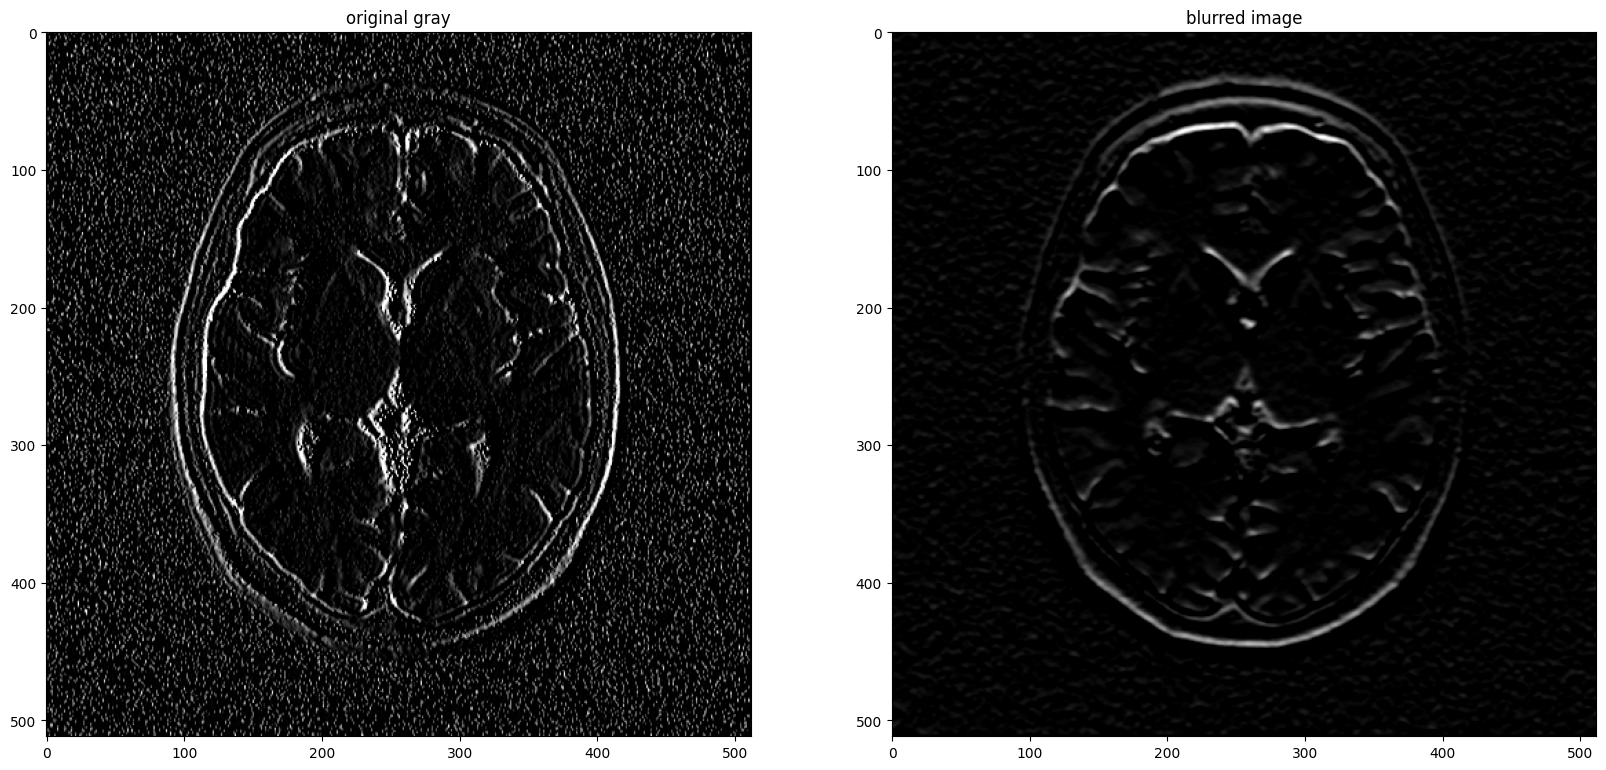

In [15]:
# High-pass filter 
sobel_x = np.array([
    [ -1, 0, 1], 
    [ -2, 0, 2], 
    [ -1, 0, 1]])
sobel_y = np.array([
    [ -1, -2, -1], 
    [ 0, 0, 0], 
    [ 1, 2, 1]])
filtered = cv2.filter2D(gray, -1, sobel_x)
filtered_blurred = cv2.filter2D(gray_blur, -1, sobel_y)
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,10))
ax1.set_title('original gray')
ax1.imshow(filtered, cmap='gray')
ax2.set_title('blurred image')
ax2.imshow(filtered_blurred, cmap='gray');

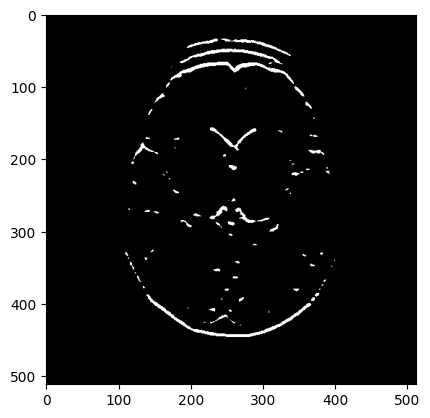

In [17]:
# Create threshold that sets all the filtered pixels to white
# Above a certain threshold
retval, binary_image = cv2.threshold(
    filtered_blurred, 70, 255, cv2.THRESH_BINARY)
plt.imshow(binary_image, cmap='gray');